In [180]:
Attribute_Information=f"""
Attribute Information:
InvoiceNo: Invoice number. Nominal, a 6-digit integral number uniquely assigned to each transaction. If this code starts with letter 'c', it indicates a cancellation.
StockCode: Product (item) code. Nominal, a 5-digit integral number uniquely assigned to each distinct product.
Description: Product (item) name. Nominal.
Quantity: The quantities of each product (item) per transaction. Numeric.
InvoiceDate: Invice Date and time. Numeric, the day and time when each transaction was generated.
UnitPrice: Unit price. Numeric, Product price per unit in sterling.
CustomerID: Customer number. Nominal, a 5-digit integral number uniquely assigned to each customer.
Country: Country name. Nominal, the name of the country where each customer resides.
"""

In [181]:
print(Attribute_Information)


Attribute Information:
InvoiceNo: Invoice number. Nominal, a 6-digit integral number uniquely assigned to each transaction. If this code starts with letter 'c', it indicates a cancellation.
StockCode: Product (item) code. Nominal, a 5-digit integral number uniquely assigned to each distinct product.
Description: Product (item) name. Nominal.
Quantity: The quantities of each product (item) per transaction. Numeric.
InvoiceDate: Invice Date and time. Numeric, the day and time when each transaction was generated.
UnitPrice: Unit price. Numeric, Product price per unit in sterling.
CustomerID: Customer number. Nominal, a 5-digit integral number uniquely assigned to each customer.
Country: Country name. Nominal, the name of the country where each customer resides.



In [182]:
import numpy as np
import pandas as pd
import os

In [183]:
path = 'D:\\AMIT\\matries\\sessions\\code\\final_proj\\proj_preprocess\\Online_Retail.csv'

In [184]:
df = pd.read_csv(path, encoding="ISO-8859-1")

In [185]:
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/10 8:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/10 8:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,12/1/10 8:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,12/1/10 8:28,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,12/1/10 8:34,1.69,13047.0,United Kingdom


# EDA

In [186]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [187]:
# check null values
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [188]:
# Remove rows with missing CustomerID
df = df.dropna(subset=['CustomerID'])

In [189]:
# CustomerID -> 135080 is null droped

In [190]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [191]:
df.duplicated().sum()

np.int64(5225)

In [192]:
df.drop_duplicates(inplace=True)

In [193]:
df.duplicated().sum()

np.int64(0)

In [194]:
# null & duplicates values checked

In [195]:
for i in df.columns:
  print(f'{i}: {df[i].nunique()}')

InvoiceNo: 22190
StockCode: 3684
Description: 3896
Quantity: 436
InvoiceDate: 20460
UnitPrice: 620
CustomerID: 4372
Country: 37


In [196]:
# people who deals with market = 4372

In [197]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,401604.000000,401604.000000,401604.000000
mean,12.183273,3.474064,15281.160818
std,250.283037,69.764035,1714.006089
min,-80995.000000,0.000000,12346.000000
25%,2.000000,1.250000,13939.000000
50%,5.000000,1.950000,15145.000000
75%,12.000000,3.750000,16784.000000
max,80995.000000,38970.000000,18287.000000


In [198]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 401604 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    401604 non-null  object 
 1   StockCode    401604 non-null  object 
 2   Description  401604 non-null  object 
 3   Quantity     401604 non-null  int64  
 4   InvoiceDate  401604 non-null  object 
 5   UnitPrice    401604 non-null  float64
 6   CustomerID   401604 non-null  float64
 7   Country      401604 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.6+ MB


In [199]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [ ]:
df.shape 

(392732, 8)

In [201]:
# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

C:\Users\dell\AppData\Local\Temp\ipykernel_15180\1442424268.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


In [202]:
# Remove if negative values exist in quantities and prices
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

In [203]:
df.shape

(392692, 8)

In [204]:
# Create TotalPrice column
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [205]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalPrice
count,392692.000000,392692,392692.000000,392692.000000,392692.000000
mean,13.119702,2011-07-10 19:13:07.771892480,3.125914,15287.843865,22.631500
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,13955.000000,4.950000
50%,6.000000,2011-07-31 12:02:00,1.950000,15150.000000,12.450000
75%,12.000000,2011-10-20 12:53:00,3.750000,16791.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,180.492832,NaN,22.241836,1713.539549,311.099224


In [206]:
df.shape

(392692, 9)

In [207]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  object        
 8   TotalPrice   392692 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.0+ MB


In [208]:
# Extract date features
# df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
df['DayOfWeek'] = df['InvoiceDate'].dt.dayofweek
df['Hour'] = df['InvoiceDate'].dt.hour

In [209]:
# UK -> 1 , Non_UK -> 0
df['CustomerRegion'] = df['Country'].apply(
    lambda x: 1 if x == 'United Kingdom' else 0
)

In [210]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalPrice,Month,Day,DayOfWeek,Hour,CustomerRegion
count,392692.000000,392692,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000
mean,13.119702,2011-07-10 19:13:07.771892480,3.125914,15287.843865,22.631500,7.601871,15.044656,2.606911,12.721532,0.889254
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000,1.000000,1.000000,0.000000,6.000000,0.000000
25%,2.000000,2011-04-07 11:12:00,1.250000,13955.000000,4.950000,5.000000,7.000000,1.000000,11.000000,1.000000
50%,6.000000,2011-07-31 12:02:00,1.950000,15150.000000,12.450000,8.000000,15.000000,2.000000,13.000000,1.000000
75%,12.000000,2011-10-20 12:53:00,3.750000,16791.000000,19.800000,11.000000,22.000000,4.000000,14.000000,1.000000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000,12.000000,31.000000,6.000000,20.000000,1.000000
std,180.492832,NaN,22.241836,1713.539549,311.099224,3.415015,8.652532,1.923929,2.276661,0.313818


In [211]:
print(df['TotalPrice'].quantile([0.75, 0.80, 0.85,0.90, 0.95, 0.99]))

0.75     19.80
0.80     20.80
0.85     25.92
0.90     35.40
0.95     67.50
0.99    203.52
Name: TotalPrice, dtype: float64


In [212]:
# # bining TotalPrice to SpendingLevel categories ('Low', 'Medium', 'High')
# df['SpendingLevel'] = pd.cut(
#     df['TotalPrice'],
#     bins=[0, 10, 100, df['TotalPrice'].max()],
#     labels=['Low', 'Medium', 'High']
# )

In [213]:
# # Bining based on 50th and 90th percentiles
# df['SpendingLevel'] = pd.cut(
#     df['TotalPrice'],
#     bins=[0, 12.5, 35.4, df['TotalPrice'].max()],
#     labels=['Low', 'Medium', 'High']
# )

In [214]:
# Bining based on 50th and 85th percentiles
df['SpendingLevel'] = pd.cut(
    df['TotalPrice'],
    bins=[0, 12.45, 25.92, df['TotalPrice'].max()],
    labels=['Low', 'Medium', 'High']
)

In [215]:
df['SpendingLevel'].value_counts()

SpendingLevel
Low       196351
Medium    137519
High       58822
Name: count, dtype: int64

In [216]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   InvoiceNo       392692 non-null  object        
 1   StockCode       392692 non-null  object        
 2   Description     392692 non-null  object        
 3   Quantity        392692 non-null  int64         
 4   InvoiceDate     392692 non-null  datetime64[ns]
 5   UnitPrice       392692 non-null  float64       
 6   CustomerID      392692 non-null  float64       
 7   Country         392692 non-null  object        
 8   TotalPrice      392692 non-null  float64       
 9   Month           392692 non-null  int32         
 10  Day             392692 non-null  int32         
 11  DayOfWeek       392692 non-null  int32         
 12  Hour            392692 non-null  int32         
 13  CustomerRegion  392692 non-null  int64         
 14  SpendingLevel   392692 non-null  category

# MODELING

## k-means

In [217]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt

In [218]:
df_KMeans = df.copy()

In [219]:
# Create customer features for clustering
customer_features = df_KMeans.groupby('CustomerID').agg({
    'InvoiceNo': 'nunique',  # Number of transactions
    'TotalPrice': 'sum',      # Total amount spent
    'StockCode': 'nunique',   # Variety of products
    'Quantity': 'sum',        # Total items purchased
    'InvoiceDate': lambda x: (x.max() - x.min()).days  # Customer lifetime in days
}).reset_index()

customer_features.columns = ['CustomerID',
                             'NumTransactions',
                             'TotalSpent',
                             'ProductVariety',
                             'TotalItems',
                             'CustomerLifetime']

# Calculate average transaction value
customer_features['AvgTransactionValue'] = customer_features['TotalSpent'] / customer_features['NumTransactions']

In [220]:
# Prepare features for clustering
cluster_features = customer_features[['NumTransactions', 'TotalSpent', 'ProductVariety',
                                       'TotalItems', 'AvgTransactionValue']].copy()

In [221]:
# Scale the features
scaler_clustering = StandardScaler()
cluster_features_scaled = scaler_clustering.fit_transform(cluster_features)

In [222]:
# Find optimal number of clusters using elbow method
inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(cluster_features_scaled)
    inertias.append(kmeans.inertia_)

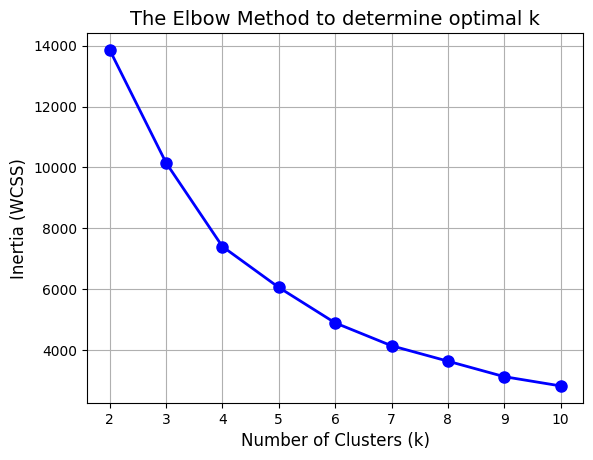

In [223]:
# Plot elbow curve
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)

plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia (WCSS)', fontsize=12)
plt.title('The Elbow Method to determine optimal k', fontsize=14)
plt.grid(True)
plt.show()

In [224]:
# Train K-Means with optimal clusters
optimal_k = 4
kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

In [225]:
# train
customer_features['Cluster'] = kmeans_model.fit(cluster_features_scaled)

In [226]:
# predict
customer_features['Cluster'] = kmeans_model.predict(cluster_features_scaled)

In [227]:
print(f"K-Means clustering completed with {optimal_k} clusters")

print(customer_features['Cluster'].value_counts().sort_index())

K-Means clustering completed with 4 clusters
Cluster
0     542
1    3779
2      15
3       2
Name: count, dtype: int64


In [228]:
analysis = customer_features.groupby('Cluster')[['TotalSpent', 'NumTransactions', 'AvgTransactionValue']].mean()

print(analysis)

            TotalSpent  NumTransactions  AvgTransactionValue
Cluster                                                     
0          6532.732177        13.256458           571.205583
1           908.340964         2.686160           346.313148
2        111212.763333        79.533333          2134.435767
3        122828.050000         1.500000         80709.925000


## Decision Tree

In [229]:
df_decision_tree = df.copy()

In [230]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn import tree

In [231]:
# year is not important all are 2010

In [232]:
df_decision_tree.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   InvoiceNo       392692 non-null  object        
 1   StockCode       392692 non-null  object        
 2   Description     392692 non-null  object        
 3   Quantity        392692 non-null  int64         
 4   InvoiceDate     392692 non-null  datetime64[ns]
 5   UnitPrice       392692 non-null  float64       
 6   CustomerID      392692 non-null  float64       
 7   Country         392692 non-null  object        
 8   TotalPrice      392692 non-null  float64       
 9   Month           392692 non-null  int32         
 10  Day             392692 non-null  int32         
 11  DayOfWeek       392692 non-null  int32         
 12  Hour            392692 non-null  int32         
 13  CustomerRegion  392692 non-null  int64         
 14  SpendingLevel   392692 non-null  category

In [233]:
selected_features = [
    'Quantity',
    'CustomerRegion',
    'Month',        
    'Day',           
    'Hour',           
    'DayOfWeek',      
]


X = df_decision_tree[selected_features]
y = df_decision_tree['SpendingLevel']

In [234]:
df['DayOfWeek'].value_counts()

DayOfWeek
3    79243
2    68040
1    65744
0    64231
6    61212
4    54222
Name: count, dtype: int64

In [235]:
df['Month'].value_counts()

Month
11    63168
10    48793
12    42696
9     39669
5     28073
6     26926
3     26870
8     26790
7     26580
4     22433
1     20988
2     19706
Name: count, dtype: int64

In [236]:
df['Day'].value_counts()

Day
6     18076
5     16127
8     15621
7     15426
17    14729
4     14632
20    14404
23    14092
14    14013
13    14003
10    13932
1     13487
28    13320
11    13206
21    12976
9     12792
18    12678
16    12583
22    12281
27    12201
2     11922
24    11921
25    11835
15    11305
3     10724
19    10700
12    10418
30     9914
26     8619
29     8033
31     6722
Name: count, dtype: int64

In [237]:
df['Quantity'].value_counts()

Quantity
1        69592
12       59826
2        57421
6        37480
4        32090
         ...  
59           1
388          1
1404         1
698          1
80995        1
Name: count, Length: 301, dtype: int64

In [238]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [239]:
X.columns

Index(['Quantity', 'CustomerRegion', 'Month', 'Day', 'Hour', 'DayOfWeek'], dtype='object')

In [240]:
y.value_counts()

SpendingLevel
Low       196351
Medium    137519
High       58822
Name: count, dtype: int64

In [241]:
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)

In [242]:
dt_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [243]:
y_pred = dt_model.predict(X_test)

In [244]:
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

        High       0.58      0.60      0.59     11730
         Low       0.79      0.73      0.76     39304
      Medium       0.59      0.64      0.62     27505

    accuracy                           0.68     78539
   macro avg       0.65      0.66      0.66     78539
weighted avg       0.69      0.68      0.69     78539



In [245]:
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': dt_model.feature_importances_})

feature_importance.sort_values(by='Importance', ascending=False)

,Feature,Importance
0,Quantity,0.881774
4,Hour,0.068430
1,CustomerRegion,0.039952
5,DayOfWeek,0.008768
3,Day,0.000717
2,Month,0.000359


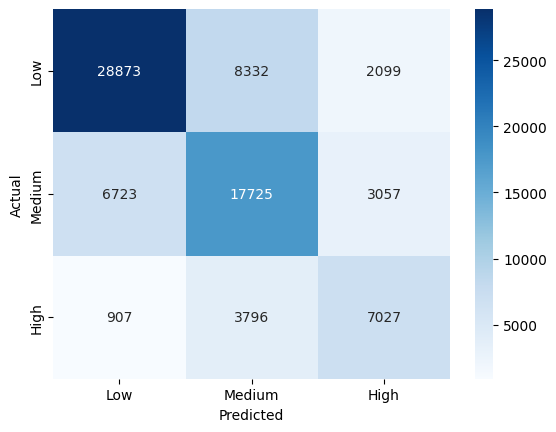

In [246]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=['Low','Medium','High'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Low','Medium','High'], yticklabels=['Low','Medium','High'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


## KNN

In [247]:
df_KNN = df.copy()

In [248]:
selected_features = [
    'Quantity',
    'CustomerRegion',
    'Month',        
    'Day',           
    'Hour',           
    'DayOfWeek',      
]


X = df_KNN[selected_features]
y = df_KNN['SpendingLevel']

In [249]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

In [250]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [251]:
scaler = StandardScaler()

In [252]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [253]:
knn_model = KNeighborsClassifier(n_neighbors=3)

In [254]:
knn_model.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [255]:
y_pred_knn = knn_model.predict(X_test_scaled)

In [256]:
print("KNN Classification Report:\n", classification_report(y_test, y_pred_knn))

KNN Classification Report:
               precision    recall  f1-score   support

        High       0.50      0.56      0.53     11730
         Low       0.77      0.77      0.77     39304
      Medium       0.62      0.59      0.61     27505

    accuracy                           0.68     78539
   macro avg       0.63      0.64      0.64     78539
weighted avg       0.68      0.68      0.68     78539



### with weight distance priority

In [257]:
# to deal with impalance data
knn_model_withClassWeight = KNeighborsClassifier(n_neighbors=3, weights='distance')

In [258]:
knn_model_withClassWeight.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [259]:
y_pred_knnC = knn_model_withClassWeight.predict(X_test_scaled)

In [260]:
print("KNN Classification Report:\n", classification_report(y_test, y_pred_knnC))

KNN Classification Report:
               precision    recall  f1-score   support

        High       0.51      0.57      0.54     11730
         Low       0.77      0.78      0.77     39304
      Medium       0.63      0.59      0.61     27505

    accuracy                           0.68     78539
   macro avg       0.64      0.64      0.64     78539
weighted avg       0.68      0.68      0.68     78539



Accociaion rule

In [261]:
df_assoc = df.copy()
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

In [263]:
df_assoc['Quantity_cat'] = pd.cut(
    df_assoc['Quantity'],
    bins=[0, 5, 20, 100000],
    labels=['Low_Qty', 'Medium_Qty', 'High_Qty']
)


In [264]:
df_assoc['TotalPrice_cat'] = pd.cut(
    df_assoc['TotalPrice'],
    bins=[0, 10, 50, 1000000],
    labels=['Low_Spend', 'Medium_Spend', 'High_Spend']
)


In [265]:
df_assoc['TimeOfDay'] = pd.cut(
    df_assoc['Hour'],
    bins=[0, 11, 17, 23],
    labels=['Morning', 'Afternoon', 'Evening']
)


In [266]:
df_assoc['DayType'] = df_assoc['DayOfWeek'].apply(
    lambda x: 'Weekend' if x >= 5 else 'Weekday'
)


In [267]:
assoc_features = df_assoc[
    ['Quantity_cat', 'TotalPrice_cat', 'TimeOfDay', 'DayType', 'CustomerRegion']
]


In [268]:
df_encoded = pd.get_dummies(assoc_features)


In [269]:
from mlxtend.frequent_patterns import apriori, association_rules

frequent_itemsets = apriori(
    df_encoded,
    min_support=0.05,
    use_colnames=True
)

frequent_itemsets.sort_values(by='support', ascending=False).head()


c:\Users\dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,support,itemsets
0,0.889254,(CustomerRegion)
9,0.844122,(DayType_Weekday)
19,0.741311,"(DayType_Weekday, CustomerRegion)"
8,0.684134,(TimeOfDay_Afternoon)
18,0.621411,"(TimeOfDay_Afternoon, CustomerRegion)"


In [270]:
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.6
)

rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']] \
    .sort_values(by='lift', ascending=False).head()


,antecedents,consequents,support,confidence,lift
264,"(DayType_Weekend, Quantity_cat_Low_Qty)","(TimeOfDay_Afternoon, TotalPrice_cat_Low_Spend...",0.067880,0.660096,2.026237
262,"(DayType_Weekend, Quantity_cat_Low_Qty, Custom...","(TimeOfDay_Afternoon, TotalPrice_cat_Low_Spend)",0.067880,0.672062,2.001695
233,"(DayType_Weekend, Quantity_cat_Low_Qty)","(TimeOfDay_Afternoon, TotalPrice_cat_Low_Spend)",0.068114,0.662374,1.972840
259,"(DayType_Weekend, TimeOfDay_Afternoon, Quantit...","(TotalPrice_cat_Low_Spend, CustomerRegion)",0.067880,0.827646,1.966956
265,"(TotalPrice_cat_Low_Spend, DayType_Weekend)","(TimeOfDay_Afternoon, Quantity_cat_Low_Qty, Cu...",0.067880,0.686869,1.945695


reg


In [271]:
X = df[
    ['Quantity', 'UnitPrice', 'Month', 'Day', 'Hour', 'CustomerRegion']
]

y = df['TotalPrice']
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [272]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [273]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [274]:
y_pred = lr_model.predict(X_test)
from sklearn.metrics import mean_squared_error, r2_score

In [275]:
from sklearn.metrics import mean_squared_error, r2_score

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


MSE: 91905.98181181774
R2 Score: 0.749412643098594


In [276]:
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
})

print(coeff_df)


          Feature  Coefficient
0        Quantity     1.044662
1       UnitPrice     1.203004
2           Month    -0.037062
3             Day    -0.028434
4            Hour    -0.356982
5  CustomerRegion    -4.932844
